In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("dataset/train_set.csv")

In [30]:
df["checkin"] = pd.to_datetime(df["checkin"])
df["checkout"] = pd.to_datetime(df["checkout"])
df["stay_nights"] = (df["checkout"] - df["checkin"]).dt.days

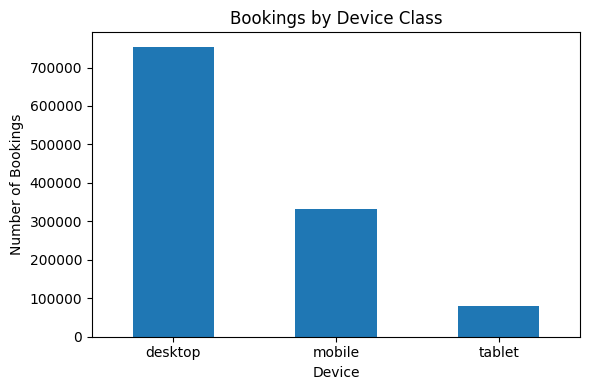

In [31]:
# Distribution of device classes
fig, ax = plt.subplots(figsize=(6, 4))
df["device_class"].value_counts().plot.bar(ax=ax)
ax.set_title("Bookings by Device Class")
ax.set_xlabel("Device")
ax.set_ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

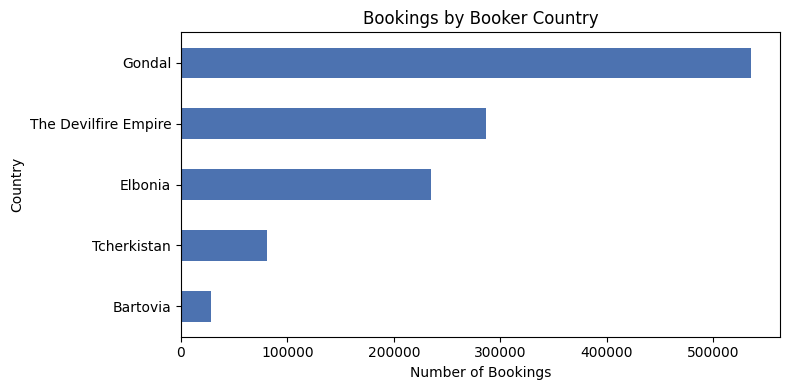

In [32]:
# Booker countries
fig, ax = plt.subplots(figsize=(8, 4))
df["booker_country"].value_counts().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Bookings by Booker Country")
ax.set_xlabel("Number of Bookings")
ax.set_ylabel("Country")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

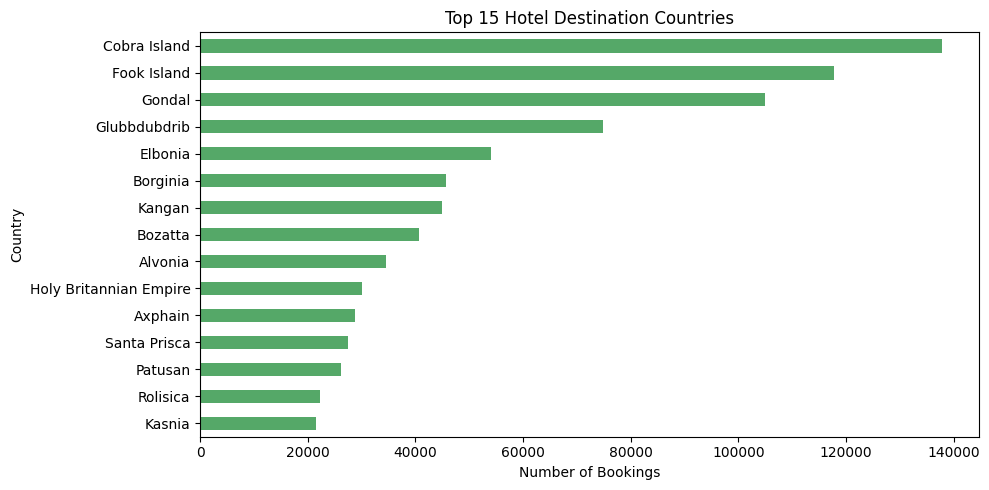

In [33]:
# Top 15 hotel destination countries
fig, ax = plt.subplots(figsize=(10, 5))
df["hotel_country"].value_counts().head(15).plot.barh(ax=ax, color="#55A868")
ax.set_title("Top 15 Hotel Destination Countries")
ax.set_xlabel("Number of Bookings")
ax.set_ylabel("Country")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

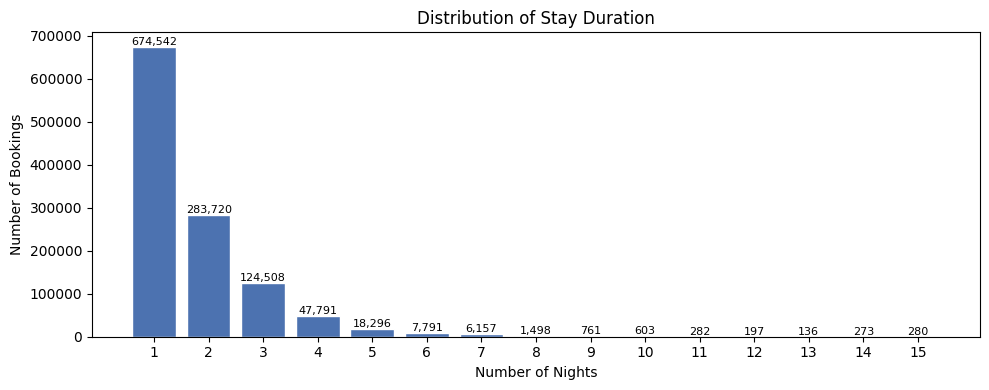

In [34]:
# Distribution of stay duration (nights)
fig, ax = plt.subplots(figsize=(10, 4))
stay_counts = df["stay_nights"].clip(upper=15).value_counts().sort_index()
ax.bar(stay_counts.index, stay_counts.values, color="#4C72B0", edgecolor="white")
for x, y in zip(stay_counts.index, stay_counts.values):
    ax.text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=8)
ax.set_title("Distribution of Stay Duration")
ax.set_xlabel("Number of Nights")
ax.set_ylabel("Number of Bookings")
ax.set_xticks(stay_counts.index)
plt.tight_layout()
plt.show()

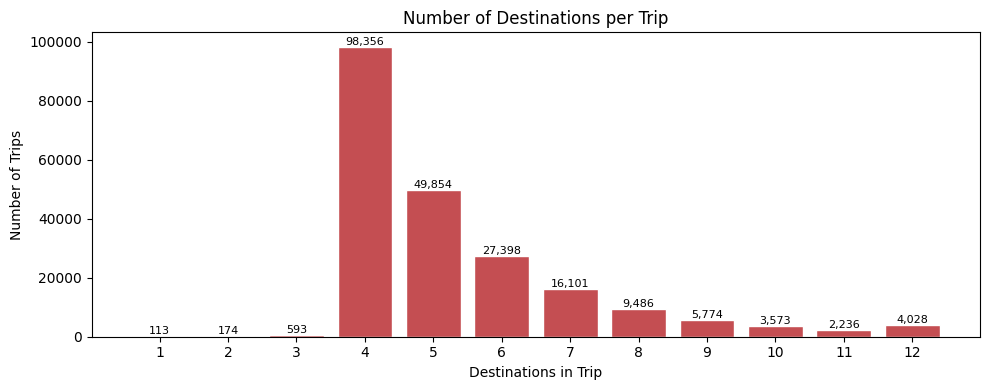

In [35]:
# Number of destinations per trip
trip_counts = df.groupby("utrip_id").size().clip(upper=12).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(trip_counts.index, trip_counts.values, color="#C44E52", edgecolor="white")
for x, y in zip(trip_counts.index, trip_counts.values):
    ax.text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=8)
ax.set_title("Number of Destinations per Trip")
ax.set_xlabel("Destinations in Trip")
ax.set_ylabel("Number of Trips")
ax.set_xticks(trip_counts.index)
plt.tight_layout()
plt.show()

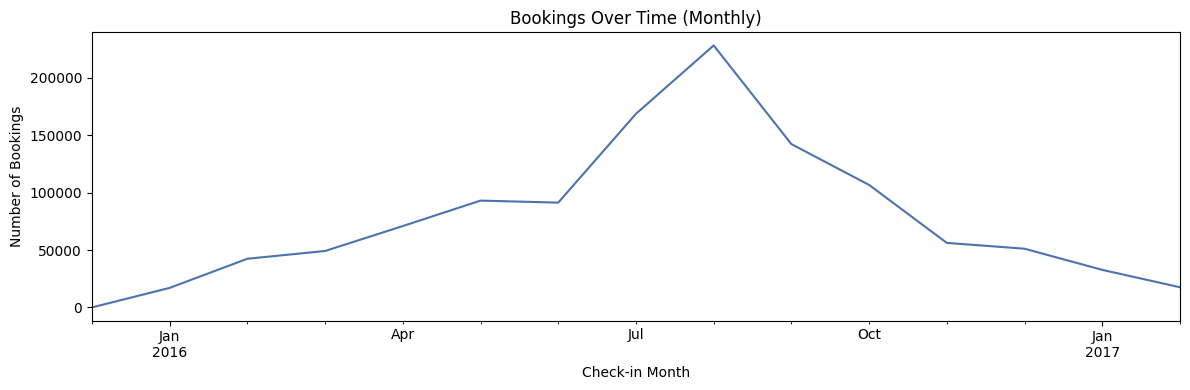

In [36]:
# Bookings over time (monthly)
fig, ax = plt.subplots(figsize=(12, 4))
df.set_index("checkin").resample("ME").size().plot(ax=ax, color="#4C72B0")
ax.set_title("Bookings Over Time (Monthly)")
ax.set_xlabel("Check-in Month")
ax.set_ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

# TODO : In the pdf
Loss issues on MPS

➜  ml-recommendations-travel git:(main) ✗ uv run main.py
Using device: mps
Loading and preprocessing trips...
  217573 trips, 39901 unique cities
Epoch 1/5  loss=7.9572  val_top4_acc=0.1024
Epoch 2/5  loss=7.5987  val_top4_acc=0.0992
Epoch 3/5  loss=7.5299  val_top4_acc=0.1055
Epoch 4/5  loss=7.4936  val_top4_acc=0.1067
Epoch 5/5  loss=7.5113  val_top4_acc=0.0962

With CPU

➜  ml-recommendations-travel git:(main) ✗ uv run main.py
Using device: cpu
Loading and preprocessing trips...
  217573 trips, 39901 unique cities
Epoch 1/5  loss=5.9626  val_top4_acc=0.4186
Epoch 2/5  loss=4.4965  val_top4_acc=0.4550
Epoch 3/5  loss=4.0931  val_top4_acc=0.4717
Epoch 4/5  loss=3.8128  val_top4_acc=0.4789
Epoch 5/5  loss=3.5772  val_top4_acc=0.4848